In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

In [63]:
import pandas as pd
df = pd.read_csv('JobVision_Jobposts_Dataset.csv')

In [64]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df.head()

,RowNumber,Jobpost_RawTitle,Jobpost_PreferredGender,Jobpost_ProvinceFa,Jobpost_ProvinceEn,Jobpost_WorkTypeFa,Jobpost_WorkTypeEn,Jobpost_SalaryCanBeShown,Jobpost_MinSalary,Jobpost_MaxSalary,Jobpost_MainJobCategory,Jobpost_SecondaryJobCategories,Jobpost_IndustryFa,Jobpost_IndustryEn,Jobpost_RequiredExperienceYears,Jobpost_RequiredRelatedExperienceInThisIndustry,Jobpost_CompanyWorkTimesDescription,Jobpost_LanguageSkills,Jobpost_SoftwareSkills,Jobpost_AcademicFields,Jobpost_BenefitFa,Jobpost_BenefitEn,Jobpost_HasDisabilitySupport,Jobpost_RequiredMinAge,Jobpost_RequiredMaxAge,Jobpost_RequiredMilitaryServiceCard,Jobpost_IsRemote,Jobpost_IsInternship,Jobpost_PriorityWithLocalCandidate,Jobpost_ActivationTime_YEAR_MONTH,Company_AgeFromEstablishmentYear,Company_ProvinceFa,Company_ProvinceEn,Company_CityFa,Company_CityEn,Comany_CompanyOwnershipTypesFa,Company_CompanyOwnershipTypesEn,Company_SizeFa,Company_SizeEn,Company_ActivityTypeFa,Company_ActivityTypeEn,Company_IndustryFa,Company_IndustryEn
0,1,مهندس مکانیک,تفاوتی ندارد,تهران,Tehran,پاره وقت,Part Time,False,NaN,NaN,مهندسی مکانیک / مهندسی هوا و فضا,NaN,تولیدی / صنعتی,Manufacturing & Production,1,False,نیمه وقت,NaN,NaN,"[{""FieldType"":""مهندسی مکانیک"",""DegreeLevel"":""کارشناسی""}]",NaN,NaN,NaN,25.0,35.0,False,False,False,False,2022-04,more than 20 years,تهران,Tehran,تهران,Tehran,خصوصی,Privately held,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی,Iranian company dealing only with Iranian entities,"ساختمان / مصالح و تجهیزات ساختمانی,تولیدی / صنعتی","Construction / Building Materials & Equipment,Manufacturing & Production"
1,2,طراح و گرافیست,تفاوتی ندارد,تهران,Tehran,تمام وقت,Full Time,False,NaN,NaN,طراحی گرافیک / طراحی انیمیشن و موشن گرافیک,NaN,طراحی / گرافیک / هنر,Design / Arts,3,False,تمام وقت,NaN,"[{""TitleFa"":""ایلاستریتور,ایلوستریتور"",""TitleEn"":""Adobe Illustrator"",""Level"":""متوسط""},{""TitleFa"":""ایندیزاین,این دیزاین"",""TitleEn"":""Adobe Indesign"",""Level"":""متوسط""},{""TitleFa"":""پریمیر"",""TitleEn"":""Adobe Premiere"",""Level"":""متوسط""},{""TitleFa"":""فتوشاپ,فوتوشاپ"",""TitleEn"":""Adobe Photoshop"",""Level"":""متوسط""},{""TitleFa"":""کورل,کرل"",""TitleEn"":""Corel Draw"",""Level"":""متوسط""}]","[{""FieldType"":""هنر"",""DegreeLevel"":""کارشناسی""}]",NaN,NaN,NaN,23.0,33.0,False,False,False,True,2023-03,10 - 14 years,تهران,Tehran,تهران,Tehran,خصوصی,Privately held,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and foreign customers,طراحی / گرافیک / هنر,Design / Arts
2,3,برنامه نویس full-stack,تفاوتی ندارد,خراسان رضوی,Khorasan Razavi,تمام وقت,Full Time,False,NaN,NaN,توسعه نرم افزار و برنامه نویسی,NaN,اینترنت / تجارت الکترونیک / خدمات آنلاین,Internet Provider / E-commerce / Online Services,3,True,8,NaN,"[{""TitleFa"":""اچ تی ام ال,سی اس اس"",""TitleEn"":""Html & CSS"",""Level"":""پیشرفته""},{""TitleFa"":""جاوا اسکریپت"",""TitleEn"":""JavaScript"",""Level"":""پیشرفته""},{""TitleFa"":"""",""TitleEn"":""PostgreSql"",""Level"":""پیشرفته""},{""TitleFa"":""ری اکت"",""TitleEn"":""React"",""Level"":""پیشرفته""},{""TitleFa"":"""",""TitleEn"":""Rest API"",""Level"":""پیشرفته""},{""TitleFa"":""انگولار"",""TitleEn"":""Angular"",""Level"":""پیشرفته""},{""TitleFa"":""پی اچ پی"",""TitleEn"":""PHP"",""Level"":""پیشرفته""}]","[{""FieldType"":""کامپیوتر - فناوری اطلاعات"",""DegreeLevel"":""کارشناسی ارشد""}]",NaN,NaN,NaN,23.0,35.0,True,False,False,False,2022-04,5 - 9 years,خراسان رضوی,Khorasan Razavi,مشهد,Mashhad,خصوصی,Privately held,زیر 10 نفر,Less than 10 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,Iranian company dealing with Iranian and foreign customers,"اینترنت / تجارت الکترونیک / خدمات آنلاین,شرکت های خدماتی / پیمانکاران","Internet Provider / E-commerce / Online Services,General Services / Contractor"
3,4,بازاریاب - خانم,فقط خانم,البرز,Alborz,تمام وقت,Full Time,False,NaN,NaN,فروش و بازاریابی - فروشنده / بازاریاب و ویزیتور / صندوقدار,NaN,اینترنت / تجارت الکترونیک / خدمات آنلاین,Internet Provider / 

In [65]:
df.shape

(364838, 43)

In [66]:
df.isnull().sum()

RowNumber                                               0
Jobpost_RawTitle                                        0
Jobpost_PreferredGender                                 0
Jobpost_ProvinceFa                                      0
Jobpost_ProvinceEn                                      0
Jobpost_WorkTypeFa                                      0
Jobpost_WorkTypeEn                                      0
Jobpost_SalaryCanBeShown                                0
Jobpost_MinSalary                                  244030
Jobpost_MaxSalary                                  244030
Jobpost_MainJobCategory                                 0
Jobpost_SecondaryJobCategories                     283525
Jobpost_IndustryFa                                      0
Jobpost_IndustryEn                                      0
Jobpost_RequiredExperienceYears                         0
Jobpost_RequiredRelatedExperienceInThisIndustry         0
Jobpost_CompanyWorkTimesDescription                    57
Jobpost_Langua

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364838 entries, 0 to 364837
Data columns (total 43 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   RowNumber                                        364838 non-null  int64  
 1   Jobpost_RawTitle                                 364838 non-null  object 
 2   Jobpost_PreferredGender                          364838 non-null  object 
 3   Jobpost_ProvinceFa                               364838 non-null  object 
 4   Jobpost_ProvinceEn                               364838 non-null  object 
 5   Jobpost_WorkTypeFa                               364838 non-null  object 
 6   Jobpost_WorkTypeEn                               364838 non-null  object 
 7   Jobpost_SalaryCanBeShown                         364838 non-null  bool   
 8   Jobpost_MinSalary                                120808 non-null  float64
 9   Jobpost_MaxSala

پاکسازی داده

In [68]:
df_clean1 = df.copy(deep=True)

تصمیم گیری برای ستون Jobpost_HasDisabilitySupport

مقدار خالی برای این ستون بسیار زیاد است در نتیجه چند راه برای این دیتا وجود دارد . برخی منابع توصیع به حذف ستون هایی میکنند مه بالای 70 درصد مقدار خالی دارند و این ستون حدود 95 درصد خالی دارد . 

اما طبق منابع در برخی دیتاست ها، ستون هایشان درصورت داشتن مقدار پر میشوند در غیر این صورت یعنی در این مثال اگر دارای حمایت کم توانان نباشند پر نمیشوند و خالی گذاشته میشوند.

IBM HR Analytics Dataset (IBM Watson, 2020) :
برای ستون‌هایی مثل “HasDisabilitySupport”، وقتی اکثر رکوردها خالی هستند و تنها چند مورد True یا False دارند، NaN را به False در نظر می‌گیرند.
دلیل: در فرم‌های HR، فقط شرکت‌هایی که ویژگی دارند مقدار True می‌زنن، مابقی معمولاً خالی می‌مونه → یعنی ندارد.



Kaggle: “HR Data for Diversity & Inclusion” (2021)
داده‌ها نشان می‌دهد که NaN در ستون‌های اختیاری پشتیبانی، بهتره به False تبدیل شود.
حذف NaN باعث از بین رفتن 95٪ رکوردها می‌شود که برای تحلیل منطقی نیست.


Book :“Data Cleaning in Python” (O’Reilly, 2023), 
chapter 4:
وقتی ستون بولین اختیاریه و بعضی رکوردها صریحاً False دارن، NaN هم می‌تونه به False تبدیل بشه تا ستون یکدست بشه و تحلیل منطقی باقی بمونه.


In [69]:
df['Jobpost_HasDisabilitySupport'].value_counts(dropna=False)

Jobpost_HasDisabilitySupport
NaN      346909
True      16148
False      1781
Name: count, dtype: int64

In [70]:
df_clean1['Jobpost_HasDisabilitySupport'] = df_clean1['Jobpost_HasDisabilitySupport'].fillna(False).astype(bool)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15572\1334632660.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean1['Jobpost_HasDisabilitySupport'] = df_clean1['Jobpost_HasDisabilitySupport'].fillna(False).astype(bool)


In [71]:
df_clean1['Jobpost_HasDisabilitySupport'].value_counts(dropna=False)

Jobpost_HasDisabilitySupport
False    348690
True      16148
Name: count, dtype: int64

In [72]:
df_clean1['Jobpost_SecondaryJobCategories'] = df_clean1['Jobpost_SecondaryJobCategories'].fillna('نامشخص')


In [73]:
df_clean1['Jobpost_LanguageSkills'] = df_clean1['Jobpost_LanguageSkills'].fillna('نامشخص')

In [74]:
df_clean1['Jobpost_SoftwareSkills'] = df_clean1['Jobpost_SoftwareSkills'].fillna('نامشخص')

In [75]:
df_clean1['Company_CityFa'] = df_clean1['Company_CityFa'].fillna('نامشخص')

In [76]:
df_clean1['Comany_CompanyOwnershipTypesFa'] = df_clean1['Comany_CompanyOwnershipTypesFa'].fillna('نامشخص')

In [77]:
df_clean1['Company_ActivityTypeFa'] = df_clean1['Company_ActivityTypeFa'].fillna('نامشخص')

In [78]:
df_clean1.isnull().sum()

RowNumber                                               0
Jobpost_RawTitle                                        0
Jobpost_PreferredGender                                 0
Jobpost_ProvinceFa                                      0
Jobpost_ProvinceEn                                      0
Jobpost_WorkTypeFa                                      0
Jobpost_WorkTypeEn                                      0
Jobpost_SalaryCanBeShown                                0
Jobpost_MinSalary                                  244030
Jobpost_MaxSalary                                  244030
Jobpost_MainJobCategory                                 0
Jobpost_SecondaryJobCategories                          0
Jobpost_IndustryFa                                      0
Jobpost_IndustryEn                                      0
Jobpost_RequiredExperienceYears                         0
Jobpost_RequiredRelatedExperienceInThisIndustry         0
Jobpost_CompanyWorkTimesDescription                    57
Jobpost_Langua

In [79]:
df_clean1['Jobpost_CompanyWorkTimesDescription'] = df_clean1['Jobpost_CompanyWorkTimesDescription'].fillna('نامشخص')

ستون های min , max salary

<Axes: >

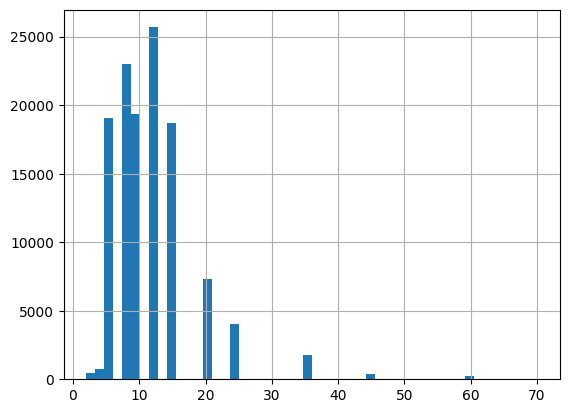

In [80]:
df[['Jobpost_MinSalary', 'Jobpost_MaxSalary']].describe()
df['Jobpost_MinSalary'].hist(bins=50)


In [81]:
print(f"Skewness (MinSalary) = {df['Jobpost_MinSalary'].skew()}")
print(f"Skewness (MaxSalary) = {df['Jobpost_MaxSalary'].skew()}")
print(f"Kurtosis (MinSalary) = {df['Jobpost_MinSalary'].kurt()}")
print(f"Kurtosis (MaxSalary) = {df['Jobpost_MaxSalary'].kurt()}")


Skewness (MinSalary) = 2.6470682776233794
Skewness (MaxSalary) = 2.6874177538944926
Kurtosis (MinSalary) = 12.311022990445359
Kurtosis (MaxSalary) = 12.196431528186196


چون داده‌هامون چولگی زیاد (۲.۶) و کشیدگی بالای ۱۲ دارن، پس باید حقوق‌های خالی را با مقدار میانه (Median) پر کنیم تا اثر چند حقوق خیلی بالا باعث اشتباه نشود.

In [82]:
median_min = df_clean1['Jobpost_MinSalary'].median()
median_max = df_clean1['Jobpost_MaxSalary'].median()

df_clean1['Jobpost_MinSalary'].fillna(median_min, inplace=True)
df_clean1['Jobpost_MaxSalary'].fillna(median_max, inplace=True)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15572\482559877.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean1['Jobpost_MinSalary'].fillna(median_min, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15572\482559877.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [83]:
df_clean1.isnull().sum()

RowNumber                                               0
Jobpost_RawTitle                                        0
Jobpost_PreferredGender                                 0
Jobpost_ProvinceFa                                      0
Jobpost_ProvinceEn                                      0
Jobpost_WorkTypeFa                                      0
Jobpost_WorkTypeEn                                      0
Jobpost_SalaryCanBeShown                                0
Jobpost_MinSalary                                       0
Jobpost_MaxSalary                                       0
Jobpost_MainJobCategory                                 0
Jobpost_SecondaryJobCategories                          0
Jobpost_IndustryFa                                      0
Jobpost_IndustryEn                                      0
Jobpost_RequiredExperienceYears                         0
Jobpost_RequiredRelatedExperienceInThisIndustry         0
Jobpost_CompanyWorkTimesDescription                     0
Jobpost_Langua

In [84]:
print(f"Skewness (MinSalary) = {df_clean1['Jobpost_RequiredMinAge'].skew()}")
print(f"Skewness (MaxSalary) = {df_clean1['Jobpost_RequiredMaxAge'].skew()}")

Skewness (MinSalary) = 0.8769471701505699
Skewness (MaxSalary) = 0.5052257021567689


طبق (Wes McKinney, 2022):

وقتی چولگی کم است (کمتر از ۰.۵) میانگین معقول است؛ اگر چولگی متوسط باشد (۰.۵ تا ۱)، بهتر است از میانه استفاده شود تا اثر مقادیر پرت کاهش یابد.

In [85]:
median_min_age = df_clean1['Jobpost_RequiredMinAge'].median()
median_max_age = df_clean1['Jobpost_RequiredMaxAge'].median()

df_clean1['Jobpost_RequiredMinAge'] = df_clean1['Jobpost_RequiredMinAge'].fillna(median_min_age)
df_clean1['Jobpost_RequiredMaxAge'] = df_clean1['Jobpost_RequiredMaxAge'].fillna(median_max_age)


In [86]:
df_clean1['Jobpost_AcademicFields'] = df_clean1['Jobpost_AcademicFields'].fillna('نامشخص')
df_clean1['HasAcademicField'] = df_clean1['Jobpost_AcademicFields'] != 'نامشخص'




In [87]:
df_clean1['Jobpost_BenefitFa'] = df_clean1['Jobpost_BenefitFa'].fillna('نامشخص')
df_clean1['HasBenefit'] = df_clean1['Jobpost_BenefitFa'] != 'نامشخص'

In [88]:
df_clean1.drop(columns=['Jobpost_BenefitEn'], inplace=True)


In [89]:
df_clean1.drop(columns=['Company_IndustryEn'], inplace=True)

In [90]:
df_clean1.drop(columns=['Company_ProvinceEn'], inplace=True)

In [91]:
df_clean1.drop(columns=['Jobpost_IndustryEn'], inplace=True)

In [92]:
df_clean1.drop(columns=['Jobpost_WorkTypeEn'], inplace=True)

In [93]:
df_clean1.drop(columns=['Company_CompanyOwnershipTypesEn'], inplace=True)

In [94]:
df_clean1.drop(columns=['Company_CityEn'], inplace=True)

In [95]:
df_clean1.drop(columns=['Jobpost_ProvinceEn'], inplace=True)

In [96]:
df_clean1.drop(columns=['Company_ActivityTypeEn'], inplace=True)

In [97]:

df_clean1.drop(columns=['RowNumber'], inplace=True)


In [98]:
df_clean2 = df_clean1.copy(deep=True)

In [99]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df_clean2.sample(30)

,Jobpost_RawTitle,Jobpost_PreferredGender,Jobpost_ProvinceFa,Jobpost_WorkTypeFa,Jobpost_SalaryCanBeShown,Jobpost_MinSalary,Jobpost_MaxSalary,Jobpost_MainJobCategory,Jobpost_SecondaryJobCategories,Jobpost_IndustryFa,Jobpost_RequiredExperienceYears,Jobpost_RequiredRelatedExperienceInThisIndustry,Jobpost_CompanyWorkTimesDescription,Jobpost_LanguageSkills,Jobpost_SoftwareSkills,Jobpost_AcademicFields,Jobpost_BenefitFa,Jobpost_HasDisabilitySupport,Jobpost_RequiredMinAge,Jobpost_RequiredMaxAge,Jobpost_RequiredMilitaryServiceCard,Jobpost_IsRemote,Jobpost_IsInternship,Jobpost_PriorityWithLocalCandidate,Jobpost_ActivationTime_YEAR_MONTH,Company_AgeFromEstablishmentYear,Company_ProvinceFa,Company_CityFa,Comany_CompanyOwnershipTypesFa,Company_SizeFa,Company_SizeEn,Company_ActivityTypeFa,Company_IndustryFa,HasAcademicField,HasBenefit
234639,Front-End Developer,تفاوتی ندارد,اصفهان,قراردادی / پروژه ای,False,10.0,12.0,توسعه نرم افزار و برنامه نویسی,نامشخص,فناوری اطلاعات / نرم افزار و سخت افزار,2,True,منعطف,نامشخص,"[{""TitleFa"":""ری اکت"",""TitleEn"":""React"",""Level"":""متوسط""},{""TitleFa"":""اچ تی ام ال,سی اس اس"",""TitleEn"":""Html & CSS"",""Level"":""متوسط""},{""TitleFa"":""جاوا اسکریپت"",""TitleEn"":""JavaScript"",""Level"":""متوسط""},{""TitleFa"":""گیت"",""TitleEn"":""GIT"",""Level"":""متوسط""}]",نامشخص,پاداش,True,21.0,31.0,False,True,False,True,2023-08,more than 20 years,تهران,تهران,نامشخص,11 تا 50 نفر,11 - 50 employees,نامشخص,"فناوری اطلاعات / نرم افزار و سخت افزار,آموزش / پژوهش,بازاریابی و تبلیغات",False,True
201201,کارشناس سئو و تولید محتوا,تفاوتی ندارد,البرز,پاره وقت,False,10.0,12.0,دیجیتال مارکتینگ و سئو,ترجمه / تولید محتوا / نویسندگی و ویراستاری,مد و کالاهای لوکس,1,False,شنبه تا چهارشنبه 9الی 21,نامشخص,"[{""TitleFa"":""وردپرس"",""TitleEn"":""Wordpress"",""Level"":""پیشرفته""},{""TitleFa"":"""",""TitleEn"":""Sitebulb"",""Level"":""متوسط""},{""TitleFa"":"""",""TitleEn"":""Google Data Studio"",""Level"":""متوسط""},{""TitleFa"":""گوگل تگ منیجر"",""TitleEn"":""Google Tag Manager"",""Level"":""متوسط""},{""TitleFa"":""گوگل سرچ کنسول"",""TitleEn"":""Google Search Console"",""Level"":""متوسط""}]",نامشخص,نامشخص,False,24.0,37.0,False,True,False,False,2023-07,more than 20 years,البرز,کرج,نامشخص,زیر 10 نفر,Less than 10 employees,نامشخص,مد و کالاهای لوکس,False,False
304233,کارشناس فروش حضوری,تفاوتی ندارد,اصفهان,تمام وقت,False,10.0,12.0,فروش و بازاریابی - فروشنده / بازاریاب و ویزیتور / صندوقدار,فروش و بازاریابی - سطوح کارشناسی و مدیریتی,خرده فروشی / مرکز خرید / فروشگاه,1,False,کل ایام هفته - به صورت چرخشی,نامشخص,"[{""TitleFa"":""ورد"",""TitleEn"":""Microsoft Word"",""Level"":""متوسط""},{""TitleFa"":""اکسل"",""TitleEn"":""Microsoft Excel"",""Level"":""مقدماتی""}]",نامشخص,"سرویس رفت و برگشت,وام,پاداش,پورسانت,بیمه درمان تکمیلی,پارکینگ,ساعت کاری منعطف,بن خرید,ناهار,میان وعده,بسته ها و هدایای مناسبتی",False,22.0,40.0,False,False,False,True,2024-01,more than 20 years,قم,قم,نامشخص,1001 تا 5000 نفر,1001 - 5000 employees,نامشخص,"تجارت / بازرگانی,خرده فروشی / مرکز خرید / فروشگاه",False,True
315707,اپراتور تمیزکاری و پلیسه گیری قطعات دایکست,فقط آقا,قزوین,تمام وقت,True,8.0,10.0,کارگر ساده / نیروی خدماتی,نامشخص,خودرو و صنایع وابسته,0,False,شنبه تا چهارشنبه از ساعت 8 الی 17/15 - روزهای پنج شنبه و جمعه بر حسب نیاز,نامشخص,نامشخص,نامشخص,"سرویس رفت و برگشت,بیمه درمان تکمیلی,پارکینگ,ناهار,پزشک سازمانی,بسته ها و هدایای مناسبتی,میان وعده",True,24.0,37.0,False,False,False,False,2023-12,more than 20 years,قزوین,شهر صنعتی البرز,خصوصی,201 تا 500 نفر,201 - 500 employees,شرکت ایرانی دارای مشتریان داخلی و خارجی,"کالاهای الکتریکی و لوازم خانگی,خودرو و صنایع وابسته",False,True
174461,کارشناس منابع انسانی,تفاوتی ندارد,اصفهان,تمام وقت,False,10.0,12.0,منابع انسانی,نامشخص,تولیدی / صنعتی,2,True,شنبه تا پنج شنبه (08:00-16:00),نامشخص,"[{""TitleFa"":""اکسل"",""TitleEn"":""Microsoft Excel"",""Level"":""متوسط""},{""TitleFa"":""ورد"",""TitleEn"":""Microsoft Word"",""Level"":""متوسط""}]","[{""FieldType"":""علوم اجتماعی و جامعه شناسی - روانشناسی- آموزش- علوم تربیتی"",""DegreeLevel"":

ستون 
Jobpost_RawTitle_Clean

تعدادی از داده ها انگلیسی هستند
تعدادی کنار شغل جنسیت هم نوشته شده که باید پاک شود چون در ستون های دیگر مشخص شده و داده تکراری است

In [100]:

df_clean2['Jobpost_RawTitle_Clean'] = df_clean2['Jobpost_RawTitle'].str.replace(r'\s*-\s*(آقا|خانم)\.?$', '', regex=True)


In [101]:
import re
num_english = df_clean2['Jobpost_RawTitle_Clean'].apply(lambda x: bool(re.search(r'[A-Za-z]', str(x)))).sum()

total = len(df_clean2)

percent_english = (num_english / total) * 100

print(f"تعداد عنوان شغلی انگلیسی: {num_english}")
print(f"کل عنوان شغلی: {total}")
print(f"درصد انگلیسی: {percent_english:.2f}%")


تعداد عنوان شغلی انگلیسی: 39811
کل عنوان شغلی: 364838
درصد انگلیسی: 10.91%


In [102]:
df_clean2['Jobpost_RawTitle_Clean_Language'] = df_clean2['Jobpost_RawTitle_Clean'].apply(
    lambda x: 'English' if all(ord(c) < 128 for c in str(x)) else'Farsi'
)

In [103]:
df_clean2['Jobpost_PreferredGender'].value_counts(dropna=False)


Jobpost_PreferredGender
تفاوتی ندارد    203147
فقط آقا          75638
فقط خانم         46855
ترجیحاً آقا      20472
ترجیحاً خانم     18726
Name: count, dtype: int64

In [104]:
df_clean2['Jobpost_ProvinceFa'].value_counts(dropna=False)

Jobpost_ProvinceFa
تهران                   235537
اصفهان                   19445
البرز                    18983
خراسان رضوی              12471
مازندران                  7612
فارس                      6986
قزوین                     5706
آذربایجان شرقی            5341
گیلان                     5338
خوزستان                   5257
مرکزی                     5098
قم                        4931
یزد                       3897
کرمان                     3743
هرمزگان                   3017
همدان                     2242
سمنان                     2146
گلستان                    2049
آذربایجان غربی            2049
بوشهر                     1678
کرمانشاه                  1537
زنجان                     1494
سیستان و بلوچستان         1364
اردبیل                    1135
لرستان                    1065
کردستان                   1001
چهارمحال و بختیاری         834
خراسان جنوبی               775
ایلام                      704
خراسان شمالی               593
کهگیلویه و بویر احمد       481
خارج کشور           

In [105]:
df_clean2['Jobpost_RawTitle'] = df_clean2['Jobpost_RawTitle'].str.replace(
    r'\s*[-–—]?\s*(آقا|خانم|فقط|فقط آقا|فقط خانم)$',
    '',
    regex=True
)


In [106]:
df_clean2['Jobpost_RawTitle'] = df_clean2['Jobpost_RawTitle'].str.replace(
    r'\s*(آقا|خانم|فقط)(?=\s*[-–—]|$)',
    '',
    regex=True
)


In [107]:
df_clean2['Jobpost_RawTitle'] = df_clean2['Jobpost_RawTitle'].str.replace(
    r'\s*[-–—].*$',
    '',
    regex=True
)

In [108]:
df_clean2['Jobpost_WorkTypeFa'].value_counts(dropna=False)

Jobpost_WorkTypeFa
تمام وقت                318659
تمام وقت یا پاره وقت     23538
پاره وقت                 12715
قراردادی / پروژه ای       9926
Name: count, dtype: int64

In [109]:
df_clean2['Jobpost_SalaryCanBeShown'].value_counts(dropna=False)

Jobpost_SalaryCanBeShown
False    244030
True     120808
Name: count, dtype: int64

In [110]:
df_clean2['Jobpost_SalaryCanBeShown'].value_counts(dropna=False)

Jobpost_SalaryCanBeShown
False    244030
True     120808
Name: count, dtype: int64

In [111]:
df_clean2['Jobpost_MinSalary'].unique()[:20]
df_clean2['Jobpost_MaxSalary'].unique()[:20]


array([12., 15.,  3.,  5., 20.,  4.,  6.,  8., 10., 35., 25., 45., 19.,
       80., 60., 30., 70., 40., 16., 18.])

In [112]:
df_clean2['salary_status'] = (
    df['Jobpost_MinSalary'].isna() | df['Jobpost_MaxSalary'].isna()
).replace({True: 'توافقی', False: 'مشخص'})


In [113]:
df_clean2['Jobpost_MainJobCategory'].value_counts()


Jobpost_MainJobCategory
مالی و حسابداری                                               42863
فروش و بازاریابی - سطوح کارشناسی و مدیریتی                    38400
فروش و بازاریابی - فروشنده / بازاریاب و ویزیتور / صندوقدار    35576
مسئول دفتر / کارمند اداری و ثبت اطلاعات / تایپیست             24725
مهندسی صنایع / مدیریت تولید / مدیریت پروژه / مدیریت عملیات    18742
توسعه نرم افزار و برنامه نویسی                                15302
کارگر ساده / نیروی خدماتی                                     14538
شبکه / DevOps / پشتیبانی سخت افزاری و نرم افزاری              14285
دیجیتال مارکتینگ و سئو                                        13009
تکنسین فنی / تعمیرکار / کارگر ماهر                            12678
منابع انسانی                                                  10154
بازرگانی / تجارت                                              10102
خدمات و پشتیبانی مشتریان                                       8820
مهندسی مکانیک / مهندسی هوا و فضا                               8631
مهندسی برق              

In [114]:
job_category_mapping = {
    # مالی و اداری
    "مالی و حسابداری": "مالی و اداری",
    "مدیریت بیمه": "مالی و اداری",
    "حقوقی": "مالی و اداری",
    "مسئول دفتر / کارمند اداری و ثبت اطلاعات / تایپیست": "مالی و اداری",
    "منابع انسانی": "مالی و اداری",
    
    # فروش و بازاریابی
    "فروش و بازاریابی - سطوح کارشناسی و مدیریتی": "فروش و بازاریابی",
    "فروش و بازاریابی - فروشنده / بازاریاب و ویزیتور / صندوقدار": "فروش و بازاریابی",
    "مدیر فروشگاه / مدیر رستوران": "فروش و بازاریابی",
    
    # مهندسی و فنی
    "مهندسی صنایع / مدیریت تولید / مدیریت پروژه / مدیریت عملیات": "مهندسی و فنی",
    "مهندسی برق": "مهندسی و فنی",
    "مهندسی مکانیک / مهندسی هوا و فضا": "مهندسی و فنی",
    "مهندسی عمران": "مهندسی و فنی",
    "مهندسی معماری و شهرسازی": "مهندسی و فنی",
    "مهندسی شیمی / مهندسی نفت و گاز": "مهندسی و فنی",
    "مهندسی صنایع غذایی": "مهندسی و فنی",
    "مهندسی پزشکی": "مهندسی و فنی",
    "مهندسی نساجی": "مهندسی و فنی",
    "مهندسی معدن / زمین شناسی": "مهندسی و فنی",
    "مهندسی مواد و متالورژی": "مهندسی و فنی",
    "مهندسی پلیمر": "مهندسی و فنی",
    "مهندسی کشاورزی / علوم دامی": "مهندسی و فنی",
    "مهندسی انرژی / مهندسی هسته ای": "مهندسی و فنی",
    
    # تکنولوژی و نرم افزار
    "توسعه نرم افزار و برنامه نویسی": "فناوری و نرم افزار",
    "شبکه / DevOps / پشتیبانی سخت افزاری و نرم افزاری": "فناوری و نرم افزار",
    "تست نرم افزار": "فناوری و نرم افزار",
    "علوم داده / هوش مصنوعی": "فناوری و نرم افزار",
    
    # خدمات و کارگری
    "کارگر ساده / نیروی خدماتی": "خدمات",
    "تکنسین فنی / تعمیرکار / کارگر ماهر": "خدمات",
    "راننده / مسئول توزیع / پیک موتوری": "خدمات",
    "نگهبان":  "خدمات",
    
    # طراحی و هنر
    "طراحی گرافیک / طراحی انیمیشن و موشن گرافیک": "طراحی و هنر",
    "طراحی رابط و تجربه کاربری (UI/UX)": "طراحی و هنر",
    "طراحی صنعتی / نقشه کشی صنعتی": "طراحی و هنر",
    "طراحی لباس / طراحی طلا و جواهر": "طراحی و هنر",
    "عکاسی": "طراحی و هنر",
    "طراحی موسیقی و صدا": "طراحی و هنر",
    "طراحی بازی": "طراحی و هنر",
    
    # سلامت و پزشکی
    "پزشک / دندانپزشک / دامپزشک": "سلامت و پزشکی",
    "پرستار و بهیار / تکنسین حوزه سلامت و درمان / دستیار پزشک": "سلامت و پزشکی",
    "پرستار سالمند / پرستار کودک": "سلامت و پزشکی",
    "داروسازی / بیوشیمی / شیمی": "سلامت و پزشکی",
    
    # بقیه
    "دیجیتال مارکتینگ و سئو": "بازاریابی دیجیتال",
    "تحلیل و توسعه کسب و کار / استراتژی / برنامه ریزی": "تحلیل و مدیریت",
    "بازرگانی / تجارت": "بازرگانی",
    "لجستیک / حمل و نقل / انبارداری": "لجستیک و انبار",
    "آموزش / تدریس": "آموزش",
    "روانشناسی / مشاوره / علوم اجتماعی": "مشاوره و علوم اجتماعی",
    "روابط عمومی": "روابط عمومی",
    
    # مشاغل خیلی کم 
    "قفل و کلیدساز": "سایر مشاغل",
    "کفاش": "سایر مشاغل",
    "بافنده فرش (قالی باف)": "سایر مشاغل",
    "نانوا": "سایر مشاغل",
    "قصاب": "سایر مشاغل",
    "خبرنگار / روزنامه نگار": "سایر مشاغل",
}

df_clean2['Jobpost_Group'] = df_clean2['Jobpost_MainJobCategory'].map(job_category_mapping)


ستون زبان ها

In [115]:
df_clean3 = df_clean2.copy(deep=True)

In [116]:
import pandas as pd
import json

langs = []


levels_lang = []

for value in df_clean3['Jobpost_LanguageSkills']:

    if pd.isna(value) or value == 'نامشخص':
        langs.append('نامشخص')
        levels_lang.append('نامشخص')
        continue
    
   
    try:
        data = json.loads(value)
        langs.append(data[0]['Languages_TitleFa'])
        levels_lang.append(data[0]['Level'])
    except:
        langs.append('نامشخص')
        levels_lang.append('نامشخص')

df_clean3['langs'] = langs
df_clean3['levels_lang'] = levels_lang



In [117]:
first_skill = []
all_skills = []
all_levels = []

for value in df_clean3['Jobpost_SoftwareSkills']:
    if pd.isna(value) or value == 'نامشخص':
        first_skill.append('نامشخص')
        all_skills.append('نامشخص')
        all_levels.append('نامشخص')
        continue
    
    try:
        data = json.loads(value)
        first_skill.append(data[0]['TitleFa'])
        skills = [item['TitleFa'] for item in data]
        all_skills.append(', '.join(skills))
        levels = [item['Level'] for item in data]
        all_levels.append(', '.join(levels))
        
    except:
        first_skill.append('نامشخص')
        all_skills.append('نامشخص')
        all_levels.append('نامشخص')

df_clean3['first_skill'] = first_skill
df_clean3['all_skills'] = all_skills
df_clean3['all_skills_levels'] = all_levels


In [118]:



academic = []
degree = []


for value in df_clean3['Jobpost_AcademicFields']:
    
    if pd.isna(value) or value == 'نامشخص':
        academic.append('نامشخص')
        degree.append('نامشخص')
        continue
    

    try:
        data = json.loads(value)
    
        academic.append(data[0]['FieldType'])
    
        degree.append(data[0]['DegreeLevel'])
        
    except:
        academic.append('نامشخص')
        degree.append('نامشخص')


df_clean3['academic'] = academic
df_clean3['degree'] = degree




ستون Jobpost_AcademicFields

In [127]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
df_clean3.sample(2)

,Jobpost_RawTitle,Jobpost_PreferredGender,Jobpost_ProvinceFa,Jobpost_WorkTypeFa,Jobpost_SalaryCanBeShown,Jobpost_MinSalary,Jobpost_MaxSalary,Jobpost_MainJobCategory,Jobpost_SecondaryJobCategories,Jobpost_IndustryFa,Jobpost_RequiredExperienceYears,Jobpost_RequiredRelatedExperienceInThisIndustry,Jobpost_CompanyWorkTimesDescription,Jobpost_LanguageSkills,Jobpost_SoftwareSkills,Jobpost_AcademicFields,Jobpost_BenefitFa,Jobpost_HasDisabilitySupport,Jobpost_RequiredMinAge,Jobpost_RequiredMaxAge,Jobpost_RequiredMilitaryServiceCard,Jobpost_IsRemote,Jobpost_IsInternship,Jobpost_PriorityWithLocalCandidate,Jobpost_ActivationTime_YEAR_MONTH,Company_AgeFromEstablishmentYear,Company_ProvinceFa,Company_CityFa,Comany_CompanyOwnershipTypesFa,Company_SizeFa,Company_SizeEn,Company_ActivityTypeFa,Company_IndustryFa,HasAcademicField,HasBenefit,Jobpost_RawTitle_Clean,Jobpost_RawTitle_Clean_Language,salary_status,Jobpost_Group,langs,levels_lang,first_skill,all_skills,all_skills_levels,academic,degree,بیمه تکمیلی,ساعت منعطف,دورکاری,پاداش,وام,آموزش,همه_مزایا
155576,حسابدار,تفاوتی ندارد,خراسان رضوی,تمام وقت,True,6.0,8.0,مالی و حسابداری,نامشخص,کالاهای الکتریکی و لوازم خانگی,1,False,7:30 صبح الی 15:30,نامشخص,"[{""TitleFa"":""اکسل"",""TitleEn"":""Microsoft Excel"",""Level"":""متوسط""},{""TitleFa"":""اوت لوک"",""TitleEn"":""Microsoft Outlook"",""Level"":""متوسط""}]","[{""FieldType"":""مالی و حسابداری"",""DegreeLevel"":""کارشناسی""}]",نامشخص,False,24.0,35.0,False,False,False,True,2023-04,more than 20 years,خراسان رضوی,مشهد,خصوصی,51 تا 200 نفر,51 - 200 employees,شرکت ایرانی دارای مشتریان داخلی,کالاهای الکتریکی و لوازم خانگی,True,False,حسابدار,Farsi,مشخص,مالی و اداری,نامشخص,نامشخص,اکسل,"اکسل, اوت لوک","متوسط, متوسط",مالی و حسابداری,کارشناسی,0,0,0,0,0,0,نامشخص
291770,تکنسین فنی (نصب و پشتیبانی),تفاوتی ندارد,البرز,تمام وقت,True,12.0,15.0,تکنسین فنی / تعمیرکار / کارگر ماهر,مهندسی برق,خدمات مهندسی و تخصصی,1,False,شنبه تا چهارشنبه 8:30 الی 17:30- پنج شنبه ها تا ساعت 14,نامشخص,نامشخص,"[{""FieldType"":""مهندسی برق"",""DegreeLevel"":""کاردانی""}]",نامشخص,False,24.0,35.0,True,False,False,True,2023-11,15 - 19 years,گیلان,رشت,خصوصی,11 تا 50 نفر,11 - 50 employees,شرکت ایرانی دارای مشتریان داخلی,خدمات مهندسی و تخصصی,True,False,تکنسین فنی (نصب و پشتیبانی),Farsi,مشخص,خدمات,نامشخص,نامشخص,نامشخص,نامشخص,نامشخص,مهندسی برق,کاردانی,0,0,0,0,0,0,نامشخص


ستون 

In [120]:
df_clean3['Jobpost_BenefitFa'].unique()

array(['نامشخص', 'پاداش,پورسانت', 'پاداش', ...,
       'بسته ها و هدایای مناسبتی,صبحانه,فضای استراحت,میان وعده,پورسانت,پاداش,ساعت کاری منعطف',
       'سرویس رفت و برگشت,وام,پاداش,امریه\u200cی سربازی,محل سکونت سازمانی',
       'وام,پاداش,بیمه درمان تکمیلی,کمک هزینه دوره آموزشی,اتاق بازی,میان وعده,صبحانه,بسته ها و هدایای مناسبتی'],
      shape=(30352,), dtype=object)

In [121]:


بیمه_تکمیلی = []
ساعت_منعطف = []
دورکاری = []
پاداش = []
وام = []
آموزش = []
همه_مزایا = []

for value in df_clean3['Jobpost_BenefitFa']:
  
    if pd.isna(value) or value == 'نامشخص':
        بیمه_تکمیلی.append(0)
        ساعت_منعطف.append(0)
        دورکاری.append(0)
        پاداش.append(0)
        وام.append(0)
        آموزش.append(0)
        همه_مزایا.append('نامشخص')
        continue
 


    text = str(value).lower()
    بیمه_تکمیلی.append(1 if 'بیمه درمان تکمیلی' in text else 0)
    ساعت_منعطف.append(1 if 'ساعت کاری منعطف' in text else 0)
    دورکاری.append(1 if 'دورکاری' in text or 'کار از راه دور' in text else 0)
    پاداش.append(1 if 'پاداش' in text else 0)
    وام.append(1 if 'وام' in text else 0)
    آموزش.append(1 if 'آموزش' in text or 'دوره آموزشی' in text else 0)
    همه_مزایا.append(value)



df_clean3['بیمه تکمیلی'] = بیمه_تکمیلی
df_clean3['ساعت منعطف'] = ساعت_منعطف
df_clean3['دورکاری'] = دورکاری
df_clean3['پاداش'] = پاداش
df_clean3['وام'] = وام
df_clean3['آموزش'] = آموزش
df_clean3['همه_مزایا'] = همه_مزایا


In [122]:
df_clean3['Jobpost_ActivationTime_YEAR_MONTH'].unique()

array(['2022-04', '2023-03', '2023-12', '2022-07', '2023-11', '2023-10',
       '2022-05', '2023-07', '2022-11', '2023-06', '2024-01', '2022-12',
       '2023-05', '2022-10', '2023-08', '2023-09', '2023-04', '2023-02',
       '2022-09', '2023-01', '2022-06', '2024-02', '2022-08', '2024-03',
       '2022-03'], dtype=object)

In [123]:
df_clean3['Company_AgeFromEstablishmentYear'].unique()

array(['more than 20 years', '10 - 14 years', '5 - 9 years',
       '15 - 19 years', '0 - 4 years'], dtype=object)

In [124]:
df_clean3['Comany_CompanyOwnershipTypesFa'].unique()

array(['خصوصی', 'غیرانتفاعی / مردم نهاد / خیریه', 'نامشخص', 'دولتی'],
      dtype=object)

In [125]:
df_clean3['Company_IndustryFa'].unique()

array(['ساختمان / مصالح و تجهیزات ساختمانی,تولیدی / صنعتی',
       'طراحی / گرافیک / هنر',
       'اینترنت / تجارت الکترونیک / خدمات آنلاین,شرکت های خدماتی / پیمانکاران',
       ...,
       'گردشگری / هتلداری,خدمات برگزاری همایش، مجالس، سمینار و نمایشگاه,ورزشی / تفریح و سرگرمی',
       'خدمات سازمانی / مشاوره مدیریت,تولیدی / صنعتی,تجارت / بازرگانی',
       'بازاریابی و تبلیغات,کالاهای الکتریکی و لوازم خانگی,اینترنت / تجارت الکترونیک / خدمات آنلاین'],
      shape=(3561,), dtype=object)

In [126]:
df_clean3['Company_AgeFromEstablishmentYear'].unique()

array(['more than 20 years', '10 - 14 years', '5 - 9 years',
       '15 - 19 years', '0 - 4 years'], dtype=object)

In [129]:
df_clean3.to_csv('clean_jobvision.csv', index=False, encoding='utf-8-sig')